In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [10]:
# Generate synthetic dataset

X, y = make_moons(n_samples = 1000 , noise = 0.2, random_state=1)
y = y.reshape(-1, 1 )  # reshape for consistency 


# train_test_split 

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.2 , random_state=1)


In [11]:
# build a sequential model with linear activation 

def build_linear_model():
    model = Sequential([
        Dense(4, activation= "linear",input_dim = 2),  # first layer with linear activation 
        Dense(1, activation = "sigmoid")                # output layer for binary classification 
    ])

    model.compile(optimizer = Adam(learning_rate=0.2) , loss = "binary_crossentropy", metrics = ["accuracy"])

    return model

In [12]:
# build a sequential model with ReLU activation 

def build_relu_model():
    model = Sequential([
        Dense(4, activation= "relu",input_dim = 2),  # first layer with relu activation 
        Dense(1, activation = "sigmoid")                # output layer for binary classification 
    ])

    model.compile(optimizer = Adam(learning_rate=0.1) , loss = "binary_crossentropy", metrics = ["accuracy"])

    return model

In [13]:
# train and evaluate model 
def train_and_evaluate(model , X_train , X_test , y_train , y_test , epochs = 50, batch_size = 32):
    model.fit(X_train , y_train , epochs = epochs , batch_size = batch_size , verbose =0)
    y_pred = (model.predict(X_test)>0.5).astype(int)

    accuracy = accuracy_score(y_test , y_pred)

    return accuracy , y_pred

In [14]:
# initialise models 

linear_model= build_linear_model()
relu_model = build_relu_model()


# train and evaluate linear models 

print("Training linear model............ ")
linear_accuracy , linear_preds = train_and_evaluate(linear_model ,X_train , X_test , y_train , y_test )

print(f"Accuracy with linear Activation : {linear_accuracy} ")

Training linear model............ 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy with linear Activation : 0.875 


In [15]:
# train and evaluate relu models 

print("Training relu model............ ")
relu_accuracy , relu_preds = train_and_evaluate(relu_model ,X_train , X_test , y_train , y_test )

print(f"Accuracy with linear Activation : {relu_accuracy} ")

Training relu model............ 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Accuracy with linear Activation : 0.955 



Visualizing decision boundaries...
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


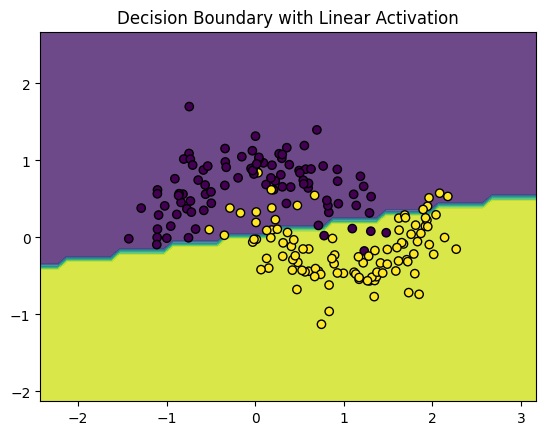

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


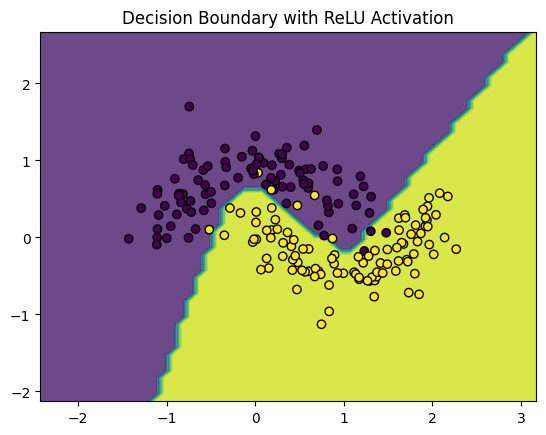

In [18]:
# Visualize decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolor="k")
    plt.title(title)
    plt.show()

# Plot decision boundaries
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, X_test, y_test, "Decision Boundary with Linear Activation")
plot_decision_boundary(relu_model, X_test, y_test, "Decision Boundary with ReLU Activation")

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]
